In [ ]:
import pandas as pd
import numpy as np


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IEEE makeup_products.csv to IEEE makeup_products.csv


In [ ]:
data = pd.read_csv('IEEE makeup_products.csv')
print(data)

                                           product_name              brand  \
0                               Barry M Sun Lit Bronzer            Barry M   
1                    L'Oreal Sculpting Contour Stick #1            L'Oreal   
2                            Benefit Sun Lit Bronzer #2            Benefit   
3                   Urban Decay Refreshing Face Mist #3        Urban Decay   
4                   Neutrogena Velvet Matte Lipstick #4         Neutrogena   
...                                                 ...                ...   
7995                  Maybelline CC+ Cream SPF 50 #7995         Maybelline   
7996  Charlotte Tilbury Moisture Renewal Lip Balm #7996  Charlotte Tilbury   
7997               Makeup Obsession Matte Bronzer #7997   Makeup Obsession   
7998             Wet n Wild Velvet Matte Lipstick #7998         Wet n Wild   
7999  Chanel Beauty Natural Skin Tinted Moisturizer ...      Chanel Beauty   

            product_type  price  rating  number_of_reviews  \
0

In [ ]:
data.head()

,product_name,brand,product_type,price,rating,number_of_reviews,ingredients,skin_type,skin_tone,finish,coverage,shade,region
0,Barry M Sun Lit Bronzer,Barry M,Bronzer,38.37,3.5,18339,"Carmine, Iron Oxides, Zinc Stearate, Silica",Oily,Fair,Matte,Light,Rich Fair,Brazil
1,L'Oreal Sculpting Contour Stick #1,L'Oreal,Contour Stick,33.92,4.4,55037,"Mica, Carnauba Wax, Dimethicone, Iron Oxides, ...",All Skin Types,Deep,Natural,Buildable,Neutral 07,Spain
2,Benefit Sun Lit Bronzer #2,Benefit,Bronzer,22.09,3.7,45132,"Zinc Stearate, Mica, Cocoa Powder, Silica, Car...",Sensitive,Medium-Tan,Satin,Light,Mauve 02,Mexico
3,Urban Decay Refreshing Face Mist #3,Urban Decay,Setting Mist,34.56,4.7,13288,"Hyaluronic Acid, Aloe Vera, Green Tea Extract,...",Dry,Medium-Tan,Dewy,Sheer,Pink D,Australia
4,Neutrogena Velvet Matte Lipstick #4,Neutrogena,Lipstick,18.49,4.9,73050,"Jojoba Oil, Castor Oil, Shea Butter, Carmine, ...",Combination,Deep,Shimmer,Medium,Medium Medium,Sweden


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_name       8000 non-null   object 
 1   brand              8000 non-null   object 
 2   product_type       8000 non-null   object 
 3   price              8000 non-null   float64
 4   rating             8000 non-null   float64
 5   number_of_reviews  8000 non-null   int64  
 6   ingredients        8000 non-null   object 
 7   skin_type          8000 non-null   object 
 8   skin_tone          8000 non-null   object 
 9   finish             8000 non-null   object 
 10  coverage           8000 non-null   object 
 11  shade              8000 non-null   object 
 12  region             8000 non-null   object 
dtypes: float64(2), int64(1), object(10)
memory usage: 812.6+ KB


In [ ]:
#creating price category
def price_category(price):
  if price < 500:
    return"Budget"
  elif price < 1000:
    return "Mid-Range"
  elif price < 2000:
    return "Premium"
  else:
    return "Luxury"
data["price_category"] = data["price"].apply(price_category)
data[["price","price_category"]].head()

,price,price_category
0,38.37,Budget
1,33.92,Budget
2,22.09,Budget
3,34.56,Budget
4,18.49,Budget


In [ ]:
#create rating category
def rating_category(rating):
 if rating >= 4.5:
   return "Excellent"
 elif rating >= 4.0:
   return "Good"
 elif rating >= 3.0:
   return "Average"
 else:
   return "Poor"

data["rating_category"] = data["rating"].apply(rating_category)

data[["rating", "rating_category"]].head()

,rating,rating_category
0,3.5,Average
1,4.4,Good
2,3.7,Average
3,4.7,Excellent
4,4.9,Excellent


In [ ]:
#create popularity score
data["popularity_score"] = (
      data["rating"] * np.log1p(data["number_of_reviews"])
)

data[["rating", "number_of_reviews", "popularity_score"]].head()

,rating,number_of_reviews,popularity_score
0,3.5,18339,34.358939
1,4.4,55037,48.029428
2,3.7,45132,39.654265
3,4.7,13288,44.625052
4,4.9,73050,54.874674


In [ ]:
#create product value score
data["product_value_score"] = (
    data["rating"] / data["price"]
)

data[["price", "rating", "product_value_score"]].head()

,price,rating,product_value_score
0,38.37,3.5,0.091217
1,33.92,4.4,0.129717
2,22.09,3.7,0.167497
3,34.56,4.7,0.135995
4,18.49,4.9,0.265008


In [ ]:
#count incredients
data["ingredient_count"] = data["ingredients"].apply(
    lambda x: len(str(x).split(","))
)

data[["ingredients", "ingredient_count"]].head()

,ingredients,ingredient_count
0,"Carmine, Iron Oxides, Zinc Stearate, Silica",4
1,"Mica, Carnauba Wax, Dimethicone, Iron Oxides, ...",5
2,"Zinc Stearate, Mica, Cocoa Powder, Silica, Car...",8
3,"Hyaluronic Acid, Aloe Vera, Green Tea Extract,...",7
4,"Jojoba Oil, Castor Oil, Shea Butter, Carmine, ...",5


In [ ]:
import numpy as np

# Re-create normalized rating, reviews, and quality index (from Zhtu2d3mjxM5)
data["rating_norm"] = data["rating"] / data["rating"].max()
data["reviews_norm"] = data["number_of_reviews"] / data["number_of_reviews"].max()
data["price_norm"] = 1 - (data["price"] / data["price"].max())

data["quality_index"] = (
    0.5 * data["rating_norm"] +
    0.3 * data["reviews_norm"] +
    0.2 * data["price_norm"]
)

# Re-create natural ingredient flag (from Np2ImtgekulZ)
natural_keywords = [
    "aloe", "vitamin", "coconut", "green tea", "jojob", "argan", "shea", "honey"
]
data["natural_ingredient_flag"] = data["ingredients"].apply(
    lambda x: 1 if any(word in str(x).lower() for word in natural_keywords) else 0
)

print("Necessary columns (rating_norm, reviews_norm, quality_index, natural_ingredient_flag) ensured.")

Necessary columns (rating_norm, reviews_norm, quality_index, natural_ingredient_flag) ensured.


In [ ]:
# natural ingredient flag
natural_keywords = [
    "aloe",
    "vitamin",
    "coconut",
    "green tea",
    "jojoba",
    "argan",
    "shea",
    "honey"
]

data["natural_ingredient_flag"] = data["ingredients"].apply(
    lambda x: 1 if any(word in str(x).lower() for word in natural_keywords) else 0
)

data[["ingredients", "natural_ingredient_flag"]].head()

,ingredients,natural_ingredient_flag
0,"Carmine, Iron Oxides, Zinc Stearate, Silica",0
1,"Mica, Carnauba Wax, Dimethicone, Iron Oxides, ...",0
2,"Zinc Stearate, Mica, Cocoa Powder, Silica, Car...",1
3,"Hyaluronic Acid, Aloe Vera, Green Tea Extract,...",1
4,"Jojoba Oil, Castor Oil, Shea Butter, Carmine, ...",1


In [ ]:
# premium brand
premium_brands = [
    "MAC",
    "Dior",
    "Estee Lauder",
    "Clinique",
    "L'Oreal",
    "Huda Beauty",
    "Charlotte Tilbury"
]

data["premium_brand"] = data["brand"].apply(
    lambda x: 1 if x in premium_brands else 0
)

data[["brand", "premium_brand"]].head()

,brand,premium_brand
0,Barry M,0
1,L'Oreal,1
2,Benefit,0
3,Urban Decay,0
4,Neutrogena,0


In [ ]:
# cosmetic suitability score
data["cosmetic_suitability_score"] = (
    0.4 * data["rating_norm"] +
    0.3 * data["reviews_norm"] +
    0.2 * data["quality_index"] +
    0.1 * data["natural_ingredient_flag"]
) * 100

data[["cosmetic_suitability_score"]].head()

,cosmetic_suitability_score
0,44.846056
1,69.611727
2,69.008934
3,64.897546
4,93.013415


In [ ]:
data.groupby('brand').size()

,0
brand,
Anastasia Beverly Hills,151
BH Cosmetics,161
Barry M,176
Beauty Bay,149
Benefit,139
Bobbi Brown,144
Catrice,159
Chanel Beauty,161
Charlotte Tilbury,176


In [ ]:
array = data.values
print(array)

[['Barry M Sun Lit Bronzer' 'Barry M' 'Bronzer' ... 0 0
  44.846055691485965]
 ["L'Oreal Sculpting Contour Stick #1" "L'Oreal" 'Contour Stick' ... 0 1
  69.61172726040819]
 ['Benefit Sun Lit Bronzer #2' 'Benefit' 'Bronzer' ... 1 0
  69.00893351500939]
 ...
 ['Makeup Obsession Matte Bronzer #7997' 'Makeup Obsession' 'Bronzer' ...
  0 0 68.40896126024977]
 ['Wet n Wild Velvet Matte Lipstick #7998' 'Wet n Wild' 'Lipstick' ... 1
  0 59.26153152993513]
 ['Chanel Beauty Natural Skin Tinted Moisturizer #7999' 'Chanel Beauty'
  'Tinted Moisturizer' ... 1 0 51.18815651989491]]


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in data.columns:
  if data[col].dtype == 'object':
    data[col] = encoder.fit_transform(data[col])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import numpy as np


In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

X = data.drop('product_type', axis=1)
Y = data['product_type']

selector = SelectKBest(score_func=chi2, k=8)

X_new = selector.fit_transform(abs(X), Y)

X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
array = data.values


In [ ]:
data['price_rating_ratio'] = (
    data['price'] / (data['rating'] + 1)
)

data['review_score'] = (
    data['number_of_reviews'] * data['rating']
)

data['quality_popularity'] = (
    data['quality_index'] *
    data['popularity_score']
)

data['value_quality'] = (
    data['product_value_score'] *
    data['quality_index']
)

In [ ]:
print(data['product_type'].value_counts())

product_type
23    347
16    347
2     345
6     342
15    342
1     341
4     339
0     334
20    333
24    333
19    332
8     331
5     321
14    314
7     311
3     310
10    309
21    307
18    303
11    298
17    298
22    297
13    291
12    291
9     284
Name: count, dtype: int64


In [ ]:
counts = data['product_type'].value_counts()

valid_classes = counts[counts > 20].index

data = data[
    data['product_type'].isin(valid_classes)
]

In [ ]:
from sklearn.model_selection import train_test_split
# Select all columns except product_name (0) and product_type (2) for X
X = array[:, [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]]
y = array[:, 2]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
data.select_dtypes(include=['object']).columns

Index([], dtype='object')

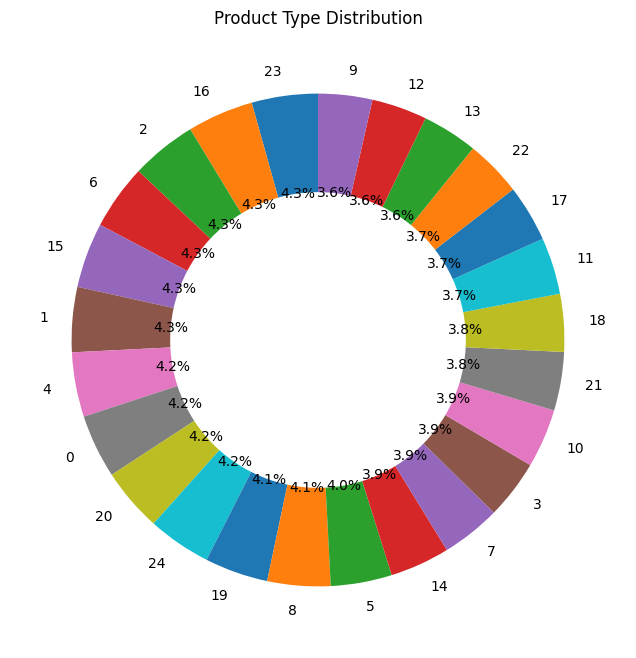

In [ ]:
import matplotlib.pyplot as plt

product_counts = data['product_type'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    product_counts,
    labels=product_counts.index,
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.4),
    startangle=90
)

plt.title('Product Type Distribution')

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in data.columns:
  if data[col].dtype == 'object':
    data[col] = encoder.fit_transform(data[col])

In [ ]:
le_dict = {}

for col in data.columns:
    if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        le_dict[col] = le

In [ ]:
remove_cols = [
    'product_name',
    'brand_name'
]

for col in remove_cols:
    if col in data.columns:
        data.drop(col, axis=1, inplace=True)

In [ ]:
from sklearn.feature_selection import mutual_info_classif


In [ ]:
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=10
)

X_selected = selector.fit_transform(X, y)

In [ ]:
from imblearn.over_sampling import SMOTE


In [ ]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X_selected,
    y
)

In [ ]:
X = data.drop('product_type', axis=1)

y = data['product_type']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
data.dtypes

,0
brand,int64
product_type,int64
price,float64
rating,float64
number_of_reviews,int64
ingredients,int64
skin_type,int64
skin_tone,int64
finish,int64
coverage,int64


In [ ]:
type(X)

pandas.core.frame.DataFrame

In [ ]:
print(type(X_train))
print(type(y_train))
print(X_train.dtype)
print(y_train[:5])

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
float64
[ 5. 23. 16.  7. 15.]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

<Figure size 800x600 with 0 Axes>

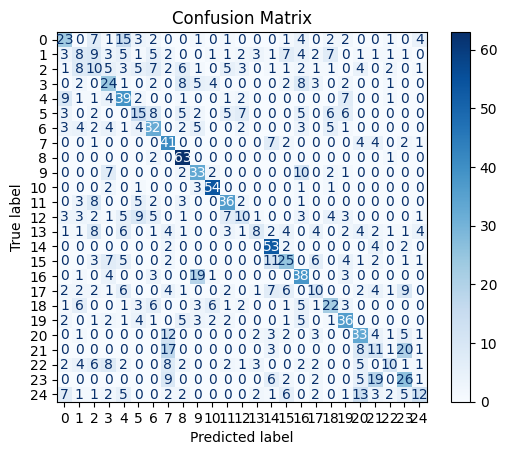

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict
y_pred = rf_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(8,6))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
!pip install shap

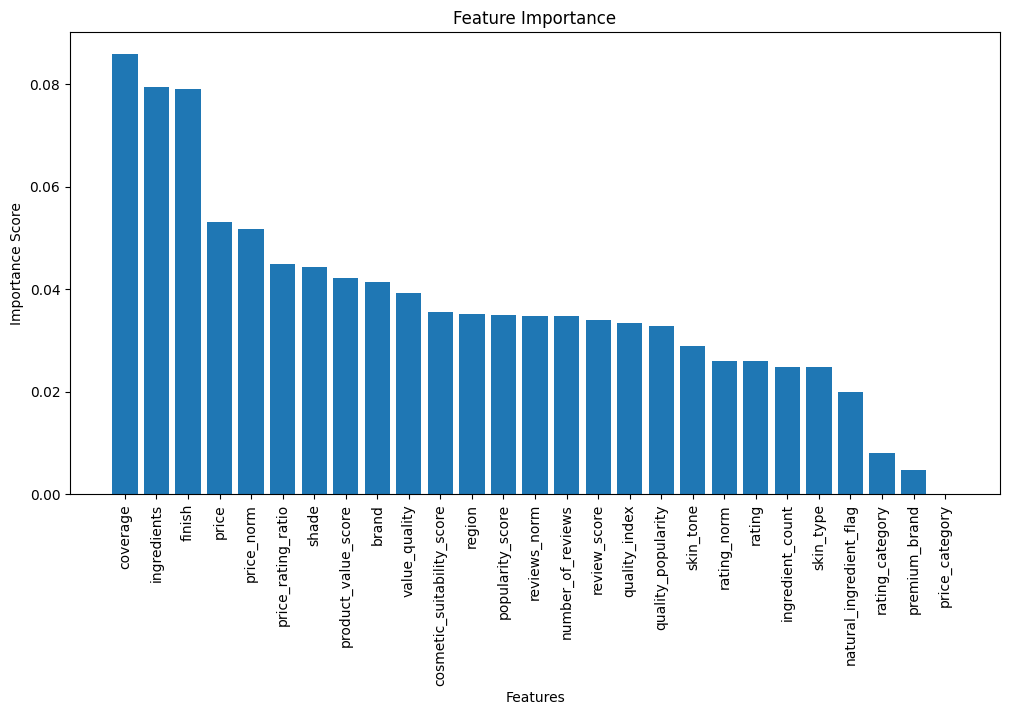

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Train model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Feature importance
importance = rf_model.feature_importances_

# Feature names
feature_names = X.columns

# Create DataFrame
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort values
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12,6))
plt.bar(feature_df['Feature'], feature_df['Importance'])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=90)
plt.show()

In [ ]:

import shap

# Create explainer
explainer = shap.TreeExplainer(rf_model)

# SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

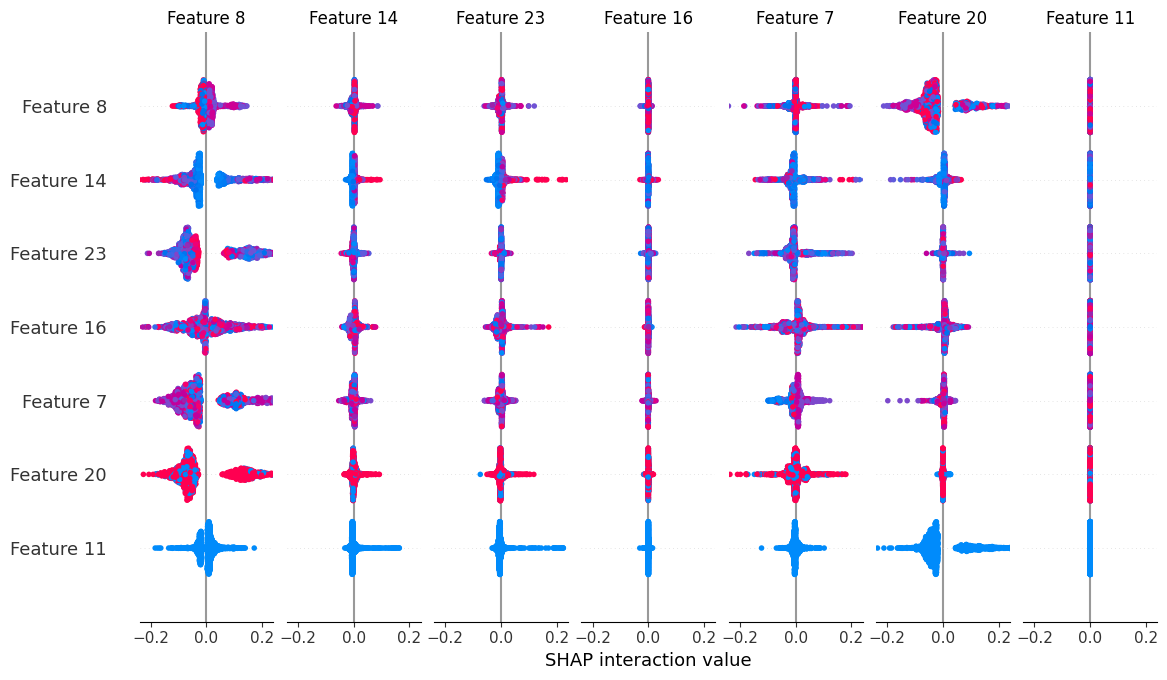

In [ ]:

import shap

# Create explainer
explainer = shap.TreeExplainer(rf_model)

# SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [ ]:
!pip install xgboost

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [ ]:
models=[]
models.append(('Decision Tree', DecisionTreeClassifier()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVM', SVC()))
models.append(('Naive Bayes', GaussianNB()))
models.append(('Random Forest', RandomForestClassifier()))
models.append(('Gradient Boosting', GradientBoostingClassifier()))
models.append(('XGBoost', XGBClassifier()))
print(models)

[('Decision Tree', DecisionTreeClassifier()), ('KNN', KNeighborsClassifier()), ('SVM', SVC()), ('Naive Bayes', GaussianNB()), ('Random Forest', RandomForestClassifier()), ('Gradient Boosting', GradientBoostingClassifier())]


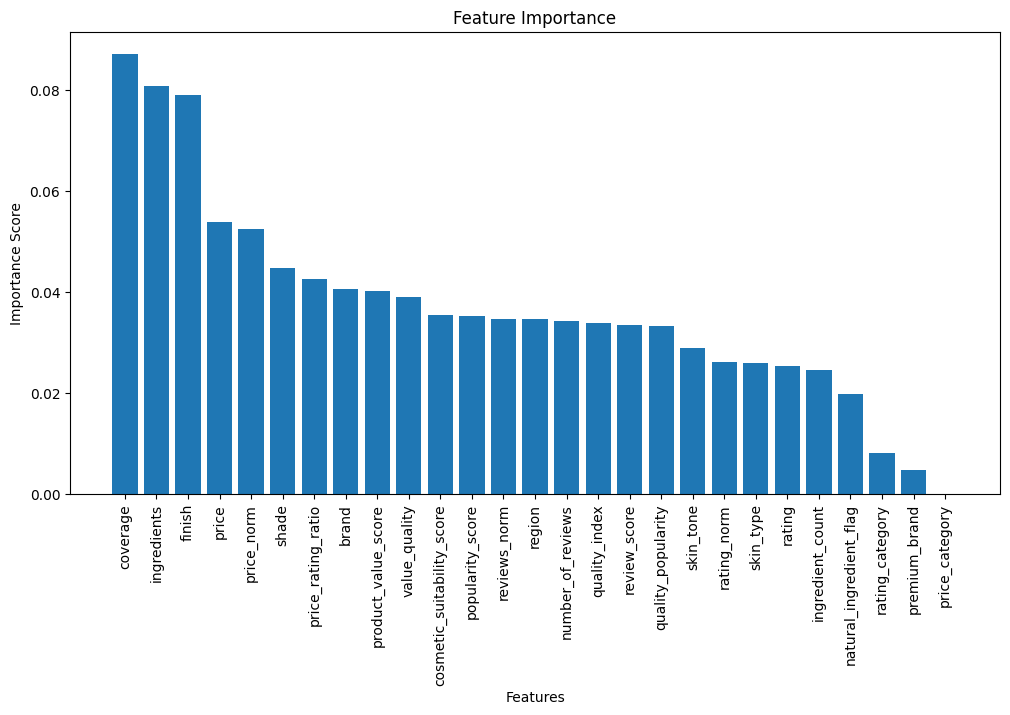

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Train model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Feature importance
importance = rf_model.feature_importances_

# Feature names
feature_names = X.columns

# Create DataFrame
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort values
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12,6))
plt.bar(feature_df['Feature'], feature_df['Importance'])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=90)
plt.show()

In [ ]:
results=[]
for name, model in models:
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average='weighted')
  recall = recall_score(y_test, y_pred, average='weighted')
  f1 = f1_score(y_test, y_pred, average='weighted')
  results.append((name, accuracy, precision, recall, f1))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results_data = pd.DataFrame(
    results,
    columns=[
        "Model",
"Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_data.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
5,Gradient Boosting,0.696875,0.705548,0.696875,0.694305
0,Decision Tree,0.430000,0.429631,0.430000,0.428462
4,Random Forest,0.425000,0.416413,0.425000,0.401729
2,SVM,0.259375,0.222576,0.259375,0.225810
3,Naive Bayes,0.258125,0.229597,0.258125,0.190296
1,KNN,0.146250,0.141864,0.146250,0.135868


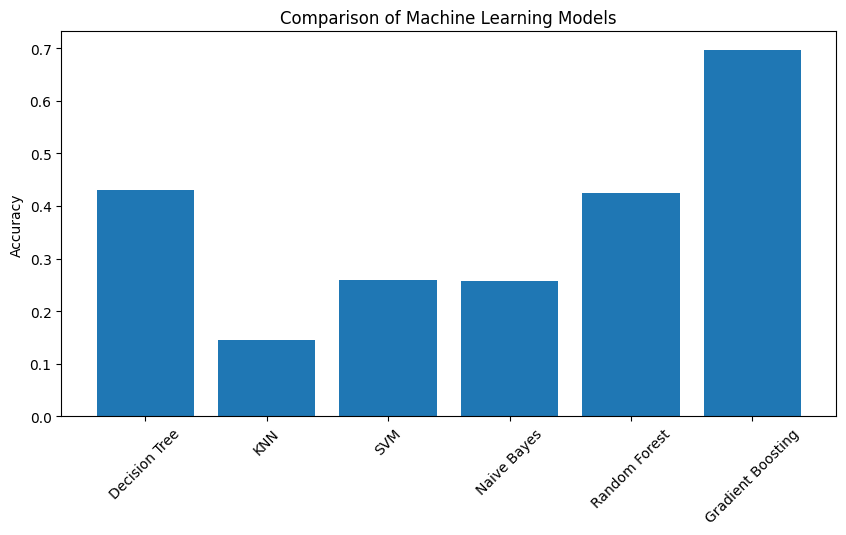

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

model_names = [r[0] for r in results]
accuracies = [r[1] for r in results]

plt.bar(model_names, accuracies)

plt.xticks(rotation=45)

plt.title("Comparison of Machine Learning Models")

plt.ylabel("Accuracy")

plt.show()

In [ ]:
classification = classification_report(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification:", classification)

In [ ]:
model = GradientBoostingClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
classification = classification_report(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification:", classification)

Accuracy: 0.69625
Classification:               precision    recall  f1-score   support

           0       0.71      0.66      0.68        67
           1       0.57      0.44      0.50        68
           2       0.58      0.43      0.50        69
           3       0.64      0.76      0.69        62
           4       0.65      0.87      0.74        68
           5       0.84      0.64      0.73        64
           6       0.69      0.74      0.71        68
           7       0.64      0.90      0.75        62
           8       0.86      0.98      0.92        66
           9       0.56      0.74      0.64        57
          10       0.97      0.98      0.98        62
          11       0.77      0.83      0.80        60
          12       0.91      0.72      0.81        58
          13       0.85      0.57      0.68        58
          14       0.77      0.90      0.83        63
          15       0.75      0.69      0.72        68
          16       0.61      0.64      0.62    